# Mezcla Gaussiana (GMM) sobre `diabetic_clean.csv`

**Objetivo:** buscar grupos de pacientes (perfiles de hospitalización) con un **modelo de mezcla gaussiana** y ver si esos grupos dicen algo sobre el **reingreso**.

### ¿Qué es una GMM?
Una GMM supone que los datos vienen de $K$ “fuentes” gaussianas mezcladas:

$$p(x)=\sum_{k=1}^{K}\pi_k\,\mathcal{N}(x;\mu_k,\Sigma_k)$$

- $\pi_k$ = **peso** (qué fracción de pacientes aporta cada componente), $\mu_k$ = **media** (perfil típico), $\Sigma_k$ = **covarianza** (forma y orientación de la nube).
- Se ajusta con **EM**: el paso E calcula las **responsabilidades** $r_{ik}=P(\text{componente }k\mid x_i)$ y el paso M re-estima $\pi,\mu,\Sigma$ ponderando con esas responsabilidades. EM sube la log-verosimilitud en cada paso, pero puede quedar en un máximo local (por eso `n_init`).

### Diferencias con K-Means
| | K-Means | GMM |
|---|---|---|
| Asignación | **dura** (cada punto a un centro) | **blanda**: cada paciente tiene una probabilidad para cada componente |
| Forma de los grupos | esferas del mismo tamaño | **elipses** de distinto tamaño, orientación y peso (según `covariance_type`) |
| Qué optimiza | inercia (distancias al centro) | verosimilitud de un modelo probabilístico → permite **BIC/AIC** y densidad por punto |

### ¿Qué supuestos se violan en estos datos? (del EDA)
1. **Todas las variables son conteos discretos** (enteros, pocas categorías: `num_procedures` tiene 7 valores, `n_meds_activos` 7, `age_num` 10). Una gaussiana es continua: puede “encogerse” sobre un solo valor repetido y obtener una verosimilitud enorme (covarianza casi singular).
2. **Visitas previas (`number_*_log`) con 87–93 % de ceros**: una masa gigante en 0 no es gaussiana.
3. **Topes y picos artificiales:** 44 % tiene exactamente 9 diagnósticos, 3.2 % tiene `num_lab_procedures = 1`.
4. **Asimetría** (colas a la derecha en estancia y medicamentos).
5. En PCA 2D **no se ven grupos separados**: lo esperable es una GMM que *parte un continuo* más que encontrar clusters naturales.

Por eso trataremos los resultados como **una segmentación útil** y no como “tipos verdaderos” de paciente.

**Revisión crítica (secciones 9 y 10):** evaluamos la estabilidad frente al jitter, elegimos K con ICL, construimos un **GMM de consenso** con 10 jitters y validamos los grupos contra el reingreso con intervalos de confianza y una línea base.

In [1]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score, davies_bouldin_score

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
# Busca la carpeta Data/ subiendo desde la carpeta actual (funciona desde la raíz del repo o desde EDA/ y Modelos/)
DATA = next(p / 'Data' for p in [Path.cwd(), *Path.cwd().parents] if (p / 'Data').is_dir())
T0 = time.perf_counter()

C = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
MUTED = '#898781'
plt.rcParams.update({
    'figure.dpi': 110, 'figure.facecolor': '#fcfcfb', 'axes.facecolor': '#fcfcfb',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': MUTED, 'axes.labelcolor': '#52514e', 'xtick.color': '#52514e', 'ytick.color': '#52514e',
    'axes.grid': True, 'grid.color': '#e6e5e0', 'grid.linewidth': 0.6, 'axes.axisbelow': True,
    'axes.titleweight': 'bold', 'axes.titlesize': 11, 'font.size': 9, 'axes.prop_cycle': plt.cycler(color=C),
})
COV_TYPES = ['full', 'diag', 'tied', 'spherical']
COV_COLOR = dict(zip(COV_TYPES, C))
SEED = 42

## 1. Carga de datos

In [2]:
d = pd.read_csv(DATA / 'diabetic_clean.csv')
print('Filas:', len(d), '| pacientes únicos:', d['patient_nbr'].nunique(), '| faltantes:', int(d.isna().sum().sum()))
print(f"Reingreso <30 días: {d['readmitted_30'].mean()*100:.1f}%  |  >30 días: {(d['readmitted']=='>30').mean()*100:.1f}%")

Filas: 69987 | pacientes únicos: 69987 | faltantes: 0
Reingreso <30 días: 9.0%  |  >30 días: 31.8%


## 2. Preparación: ¿con qué variables?

### 2.1 Espacio de features principal
Usamos las numéricas de `FEAT` del EDA **sin las tres de visitas previas**:

| Variable | Qué mide |
|---|---|
| `time_in_hospital` | días de estancia |
| `num_lab_procedures` | pruebas de laboratorio |
| `num_procedures` | procedimientos (no de laboratorio) |
| `num_medications` | medicamentos administrados |
| `number_diagnoses` | diagnósticos registrados |
| `age_num` | edad (centro del rango de 10 años) |
| `n_meds_activos` | antidiabéticos en uso |

**Por qué quitamos las visitas previas:** 87–93 % de ceros. Además de no ser gaussianas, dominarían la mezcla (ver 2.3). Las usamos solo para **interpretar**, con una bandera binaria `tuvo_visitas_previas`.

No usamos `patient_nbr` (es un ID; en el EDA vimos que se correlaciona con la época del registro), ni el objetivo `readmitted` (lo reservamos para evaluar los grupos *después*), ni categóricas en one-hot (harían singulares las covarianzas).

In [3]:
FEAT = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
        'number_diagnoses', 'age_num', 'n_meds_activos']
VISITAS = ['number_outpatient_log', 'number_emergency_log', 'number_inpatient_log']
d['tuvo_visitas_previas'] = (d[['number_outpatient', 'number_emergency', 'number_inpatient']].sum(axis=1) > 0).astype(int)

resumen = pd.DataFrame({
    'n_valores_distintos': d[FEAT + VISITAS].nunique(),
    'valor_más_frecuente': d[FEAT + VISITAS].mode().iloc[0],
    '% en ese valor': (d[FEAT + VISITAS] == d[FEAT + VISITAS].mode().iloc[0]).mean() * 100,
})
display(resumen.round(1))
print(f"Pacientes con alguna visita previa: {d['tuvo_visitas_previas'].mean()*100:.1f}%")

,n_valores_distintos,valor_más_frecuente,% en ese valor
time_in_hospital,14,3.0,17.9
num_lab_procedures,116,1.0,3.2
num_procedures,7,0.0,44.1
num_medications,75,13.0,6.1
number_diagnoses,16,9.0,43.9
age_num,10,75.0,25.4
n_meds_activos,7,1.0,44.5
number_outpatient_log,33,0.0,87.0
number_emergency_log,18,0.0,92.7
number_inpatient_log,13,0.0,88.3


Pacientes con alguna visita previa: 26.0%


La tabla confirma el problema de la **discretez**: `num_procedures` y `n_meds_activos` tienen solo 7 valores y ~44 % de los pacientes en uno solo; `number_diagnoses` tiene 44 % en 9. Las visitas previas son todavía peores (87–93 % en 0).

### 2.2 Dos transformaciones: “dequantization” (jitter) + `StandardScaler`

**StandardScaler** es obligatorio: la GMM trabaja con distancias de Mahalanobis, pero la regularización (`reg_covar`) y la inicialización con K-Means sí dependen de la escala; sin escalar, `num_lab_procedures` (0–130) dominaría a `num_procedures` (0–6).

**Jitter (dequantization):** a cada conteo entero le sumamos ruido uniforme $U(-0.5, 0.5)$ (para `age_num`, que va de 10 en 10, $U(-5, 5)$). Así “repartimos” cada valor entero sobre su intervalo y los datos se vuelven continuos **sin mezclar valores vecinos** (el ruido nunca saca a un paciente de su “escalón”, así que redondeando se recupera el dato original). Es una técnica estándar para ajustar densidades continuas a datos discretos. En la sección 3 veremos que sin este paso el BIC se vuelve errático porque la GMM “premia” componentes aplastadas sobre un solo valor entero.

Usamos **todo el dataset** (69 987 pacientes) para el modelo final; para la grilla de selección (48 modelos) usamos una muestra aleatoria de 20 000 para que tarde pocos minutos.

X completo: (69987, 7) | muestra para la grilla: (20000, 7)


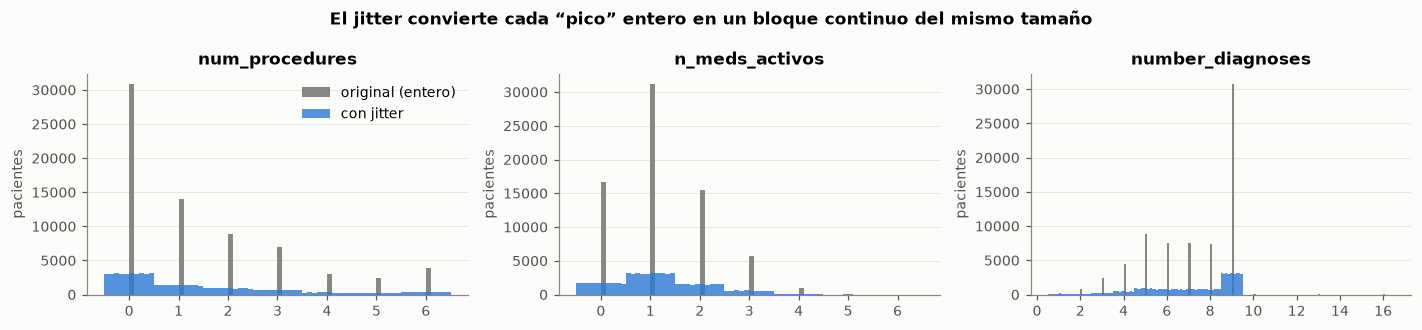

In [4]:
rng = np.random.default_rng(0)
PASO = {c: 1.0 for c in FEAT}; PASO['age_num'] = 10.0   # ancho del “escalón” de cada variable

X_raw_df = d[FEAT].astype(float)
X_jit_df = X_raw_df.copy()
for c in FEAT:
    X_jit_df[c] += rng.uniform(-0.5, 0.5, len(d)) * PASO[c]
assert all(((X_jit_df[c] - X_raw_df[c]).abs() < 0.5 * PASO[c]).all() for c in FEAT)   # nunca se sale de su “escalón”

scaler_raw = StandardScaler().fit(X_raw_df); X_raw = scaler_raw.transform(X_raw_df)
scaler = StandardScaler().fit(X_jit_df);      X = scaler.transform(X_jit_df)

idx_s = np.random.default_rng(SEED).choice(len(X), 20_000, replace=False)   # muestra para la grilla
print('X completo:', X.shape, '| muestra para la grilla:', X[idx_s].shape)

fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for ax, c in zip(axes, ['num_procedures', 'n_meds_activos', 'number_diagnoses']):
    bins = np.arange(X_raw_df[c].min() - 0.5, X_raw_df[c].max() + 0.6, 0.1)
    ax.hist(X_raw_df[c], bins=bins, color=MUTED, label='original (entero)')
    ax.hist(X_jit_df[c], bins=bins, color=C[0], alpha=0.8, label='con jitter')
    ax.set_title(c); ax.set_ylabel('pacientes'); ax.grid(axis='x', visible=False)
axes[0].legend(frameon=False)
fig.suptitle('El jitter convierte cada “pico” entero en un bloque continuo del mismo tamaño', fontweight='bold')
plt.tight_layout(); plt.show()

### 2.3 ¿Qué pasa si incluimos las visitas previas?
Ajustamos GMM `full` con K = 2…8 sobre `FEAT` **+ las 3 `number_*_log`** (misma muestra, escaladas) y medimos, para cada modelo, la **desviación estándar más pequeña** que tiene alguna componente en alguna variable (en unidades z). Un valor cercano a 0 significa una componente “aplastada” sobre un único valor: la GMM está explicando el pico en 0, no un perfil clínico.

In [5]:
def min_sd(g):
    # menor desviación estándar (en z) de cualquier componente en cualquier variable
    cov = g.covariances_
    if g.covariance_type == 'full':      v = np.array([np.diag(c) for c in cov])
    elif g.covariance_type == 'diag':    v = cov
    elif g.covariance_type == 'tied':    v = np.diag(cov)[None, :]
    else:                                v = cov[:, None]
    return float(np.sqrt(v).min())

FEAT_V = FEAT + VISITAS
Xv = StandardScaler().fit_transform(d[FEAT_V])[idx_s]
filas, modelos_v = [], {}
for k in range(2, 9):
    g = GaussianMixture(k, covariance_type='full', n_init=5, reg_covar=1e-4, max_iter=500, random_state=SEED).fit(Xv)
    modelos_v[k] = g
    filas.append({'K': k, 'BIC': g.bic(Xv), 'peso_mín': g.weights_.min(), 'sd_mínima_z': min_sd(g)})
res_v = pd.DataFrame(filas).set_index('K')
display(res_v.round(4))

g = modelos_v[4]
sd = pd.DataFrame(np.sqrt([np.diag(c) for c in g.covariances_]), columns=FEAT_V,
                  index=[f'comp {i} (peso {w:.0%})' for i, w in enumerate(g.weights_)])
print('Desviación estándar de cada componente (en z), modelo K=4 con visitas previas:')
display(sd.round(3))
mu = pd.DataFrame(g.means_, columns=FEAT_V, index=sd.index)
print('Medias (en z) de las visitas previas por componente:')
display(mu[VISITAS].round(2))

,BIC,peso_mín,sd_mínima_z
K,,,
2,235159.4836,0.2094,0.01
3,95818.0202,0.0734,0.01
4,79341.5427,0.0734,0.01
5,64014.4278,0.0734,0.01
6,23691.4658,0.0734,0.01
7,3619.3228,0.0389,0.01
8,-7641.8444,0.0182,0.01


Desviación estándar de cada componente (en z), modelo K=4 con visitas previas:


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,age_num,n_meds_activos,number_outpatient_log,number_emergency_log,number_inpatient_log
comp 0 (peso 7%),0.979,1.041,0.897,0.899,0.923,1.076,0.965,1.434,1.203,1.562
comp 1 (peso 10%),1.088,0.989,0.947,0.931,0.873,0.931,0.934,1.175,0.010,0.957
comp 2 (peso 74%),0.988,0.984,1.030,1.022,1.028,1.014,1.010,0.010,0.010,0.010
comp 3 (peso 9%),0.893,1.051,0.920,0.955,0.891,0.908,0.983,1.141,0.010,0.010


Medias (en z) de las visitas previas por componente:


,number_outpatient_log,number_emergency_log,number_inpatient_log
comp 0 (peso 7%),0.50,3.34,0.51
comp 1 (peso 10%),0.16,-0.26,2.54
comp 2 (peso 74%),-0.35,-0.26,-0.34
comp 3 (peso 9%),2.32,-0.26,-0.34


**Lectura:** con las visitas previas, desde K = 2 hay componentes con desviación estándar = 0.01 (el piso que impone `reg_covar=1e-4`, ya que $\sqrt{10^{-4}}=0.01$) justamente en las columnas `number_*_log`. En el modelo K = 4, **la componente más grande (74 % de los pacientes) es simplemente “0 visitas de los tres tipos”** (sd 0.01 en las tres) y las otras tres son “tuvo visitas de urgencias”, “tuvo hospitalizaciones previas” y “tuvo consultas externas”. Las 7 variables de la hospitalización actual casi no cambian entre componentes (sd ≈ 1 en todas). Además el BIC se desploma hasta valores **negativos** (−7 642 en K = 8), algo imposible de interpretar como “mejor ajuste”: es la densidad casi infinita de una gaussiana aplastada sobre el 0. La mezcla gasta componentes en **separar ceros de no-ceros** en lugar de describir la hospitalización actual, y el BIC mejora artificialmente por esa densidad casi infinita. Esto confirma la recomendación del EDA: **las dejamos fuera** del modelo y las usamos solo para interpretar.

## 3. Selección del modelo: BIC y AIC

$$\mathrm{BIC}=-2\,\ell(\hat\theta)+p\log n,\qquad \mathrm{AIC}=-2\,\ell(\hat\theta)+2p$$

Ambos premian la verosimilitud $\ell$ y castigan el número de parámetros $p$; **menor es mejor**. BIC castiga más ($\log n \approx 9.9$ vs 2), así que suele elegir modelos más simples. Los tipos de covarianza en sklearn:

- `full`: cada componente tiene su propia elipse con cualquier orientación ($d(d+1)/2 = 28$ parámetros por componente);
- `diag`: elipses alineadas con los ejes (7 por componente) → supone variables independientes dentro de cada grupo;
- `tied`: todas las componentes comparten **la misma** elipse;
- `spherical`: círculos, una sola varianza por componente (lo más parecido a K-Means).

### 3.1 Primero, sin jitter (datos enteros)

In [6]:
def grilla(Xg, tipos, ks):
    filas = []
    for cov in tipos:
        for k in ks:
            t = time.perf_counter()
            g = GaussianMixture(k, covariance_type=cov, n_init=5, reg_covar=1e-4, max_iter=500,
                                random_state=SEED).fit(Xg)
            filas.append({'cov': cov, 'K': k, 'BIC': g.bic(Xg), 'AIC': g.aic(Xg), 'peso_mín': g.weights_.min(),
                          'sd_mínima_z': min_sd(g), 'convergió': g.converged_, 'seg': time.perf_counter() - t})
    return pd.DataFrame(filas)

t = time.perf_counter()
res_raw = grilla(X_raw[idx_s], ['full', 'diag'], range(1, 11))
print(f'Grilla sin jitter: {time.perf_counter()-t:.0f} s')
display(res_raw.pivot(index='K', columns='cov', values=['BIC', 'sd_mínima_z']).round(3))

Grilla sin jitter: 47 s


BIC             sd_mínima_z       
cov        diag        full        diag   full
K                                             
1    397469.876  381570.613       0.992  0.992
2    372270.886  361247.903       0.234  0.239
3    313240.289  302454.897       0.010  0.010
4    275693.790  267464.938       0.010  0.010
5    273361.988  251860.238       0.010  0.010
6    258400.242  243365.860       0.010  0.010
7    233954.012  226564.193       0.010  0.010
8    242490.739  236415.127       0.010  0.010
9    221162.375  210515.937       0.010  0.010
10   236522.676  230597.685       0.010  0.010

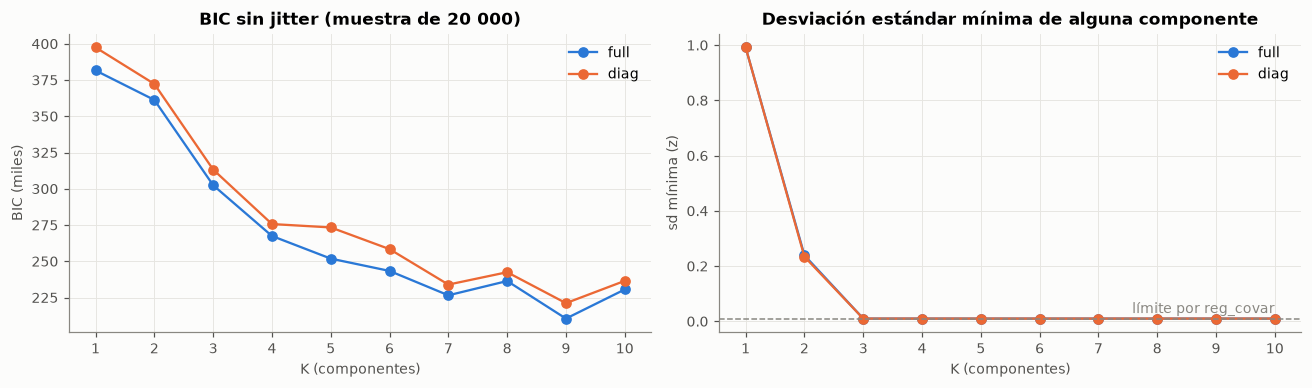

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for cov in ['full', 'diag']:
    r = res_raw[res_raw['cov'] == cov]
    axes[0].plot(r['K'], r['BIC'] / 1e3, 'o-', color=COV_COLOR[cov], label=cov)
    axes[1].plot(r['K'], r['sd_mínima_z'], 'o-', color=COV_COLOR[cov], label=cov)
axes[0].set(title='BIC sin jitter (muestra de 20 000)', xlabel='K (componentes)', ylabel='BIC (miles)')
axes[1].set(title='Desviación estándar mínima de alguna componente', xlabel='K (componentes)', ylabel='sd mínima (z)')
axes[1].axhline(0.01, color=MUTED, ls='--', lw=1); axes[1].text(10, 0.03, 'límite por reg_covar', ha='right', color=MUTED)
for ax in axes: ax.legend(frameon=False); ax.set_xticks(range(1, 11))
plt.tight_layout(); plt.show()

Sin jitter el BIC cae **a saltos** y de forma irregular (a veces sube y vuelve a bajar), sin un codo claro. La razón está en el panel derecho: a partir de pocas componentes aparece alguna con **desviación estándar ≈ 0.01 en alguna variable**, es decir, una gaussiana aplastada sobre un único valor entero (por ejemplo, todos los pacientes con `n_meds_activos = 1` o `num_procedures = 0`). Sobre un valor exacto la densidad es enorme, la log-verosimilitud sube muchísimo y el BIC “aplaude” algo que es un **artefacto de la discretez**, no un grupo de pacientes.

### 3.2 Con jitter: grilla completa K = 1…12 × 4 tipos de covarianza

In [8]:
t = time.perf_counter()
res = grilla(X[idx_s], COV_TYPES, range(1, 13))
print(f'Grilla con jitter: {time.perf_counter()-t:.0f} s  |  modelos que no convergieron: {int((~res["convergió"]).sum())}')
display(res.pivot(index='K', columns='cov', values='BIC').round(0).astype(int))

Grilla con jitter: 83 s  |  modelos que no convergieron: 0


cov,diag,full,spherical,tied
K,,,,
1,397408,381935,397353,381935
2,375170,364686,386885,376949
3,365947,355062,381234,372945
4,357690,351359,378870,372751
5,354480,349558,376571,368990
6,350505,346286,373823,365935
7,349116,344507,371528,365919
8,347042,344384,369710,364866
9,346211,343667,368040,362897


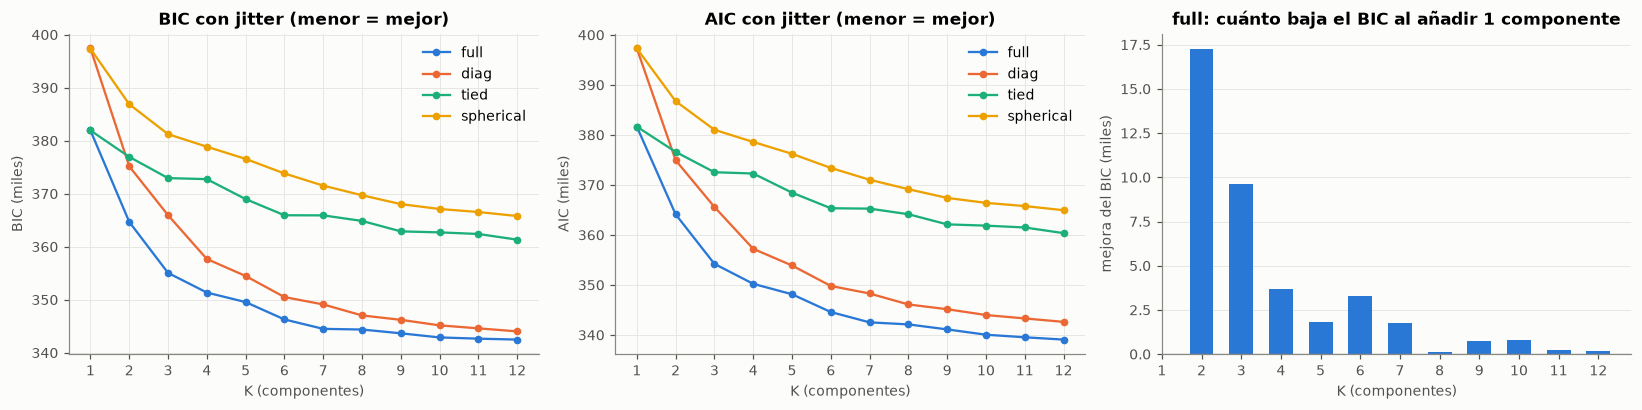

Mejor por tipo de covarianza (BIC mínimo):


,cov,K,BIC,AIC,peso_mín
23,diag,12,344033.194,342618.470,0.036
11,full,12,342485.380,339078.977,0.019
47,spherical,12,365794.839,364949.165,0.047
35,tied,12,361334.670,360362.541,0.020


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for cov in COV_TYPES:
    r = res[res['cov'] == cov]
    axes[0].plot(r['K'], r['BIC'] / 1e3, 'o-', color=COV_COLOR[cov], label=cov, ms=4)
    axes[1].plot(r['K'], r['AIC'] / 1e3, 'o-', color=COV_COLOR[cov], label=cov, ms=4)
axes[0].set(title='BIC con jitter (menor = mejor)', ylabel='BIC (miles)')
axes[1].set(title='AIC con jitter (menor = mejor)', ylabel='AIC (miles)')

r = res[res['cov'] == 'full'].set_index('K')['BIC']
mejora = -r.diff().dropna()
axes[2].bar(mejora.index, mejora.values / 1e3, color=C[0], width=0.6)
axes[2].set(title='full: cuánto baja el BIC al añadir 1 componente', ylabel='mejora del BIC (miles)')
axes[2].axhline(0, color=MUTED, lw=0.8); axes[2].grid(axis='x', visible=False)
for ax in axes:
    ax.set_xlabel('K (componentes)'); ax.set_xticks(range(1, 13))
for ax in axes[:2]: ax.legend(frameon=False)
plt.tight_layout(); plt.show()

print('Mejor por tipo de covarianza (BIC mínimo):')
display(res.loc[res.groupby('cov')['BIC'].idxmin(), ['cov', 'K', 'BIC', 'AIC', 'peso_mín']].round(3))

**Qué muestran los gráficos:**
- **`full` es el mejor tipo para todo K ≥ 2** (con K = 1, `full` y `tied` son el mismo modelo), seguido de `diag`. `tied` y `spherical` quedan muy por encima: las componentes necesitan formas y orientaciones distintas (por ejemplo, en el grupo de estancias largas la estancia y los medicamentos están correlacionados).
- Con jitter el BIC ya es una curva **suave**, pero **sigue bajando casi hasta K = 12**. Es lo esperado cuando los datos no son una mezcla de gaussianas (asimetría, topes como los 9 diagnósticos): con más componentes la GMM simplemente aproxima mejor una densidad “rara”, sin que existan más grupos reales. Por eso el BIC mínimo **no** se toma como “el número verdadero de grupos”.
- El panel derecho muestra el **codo**: las primeras componentes bajan el BIC en decenas de miles; a partir de cierto K la mejora cae a pocos miles o menos.

Elegimos K con cuatro criterios: **codo** del BIC, **estabilidad** entre semillas, **tamaño mínimo** de componente (≥ 5 %) e **interpretabilidad**.

### 3.3 Estabilidad: ¿sale el mismo modelo con otra semilla?
Para cada K ajustamos 4 modelos `full` sobre **todos** los datos con `random_state` distintos y comparamos sus asignaciones con el **ARI** (Adjusted Rand Index: 1 = particiones idénticas, 0 = coincidencia al azar).

Estabilidad: 175 s


,ARI_medio,ARI_mínimo,rango_loglik_por_paciente,BIC,peso_mín,mejora_BIC
K,,,,,,
2,0.9999,0.9999,0.0000,364686.1584,0.4984,NaN
3,0.9989,0.9984,0.0000,355062.4607,0.3025,9623.6977
4,0.9006,0.8047,0.0003,351358.9788,0.1947,3703.4819
5,0.9988,0.9979,0.0000,349557.8250,0.1441,1801.1539
6,0.9422,0.9101,0.0011,346286.2695,0.0865,3271.5555
7,0.8505,0.7107,0.0355,344507.3475,0.0376,1778.9220


Detalle para K = 4 (cada semilla con n_init=5):


,semilla,loglik_por_paciente,ARI_vs_mejor_semilla
0,0,-8.75787,0.99289
1,1,-8.75784,0.98748
2,2,-8.75754,1.00000
3,3,-8.75785,0.81520


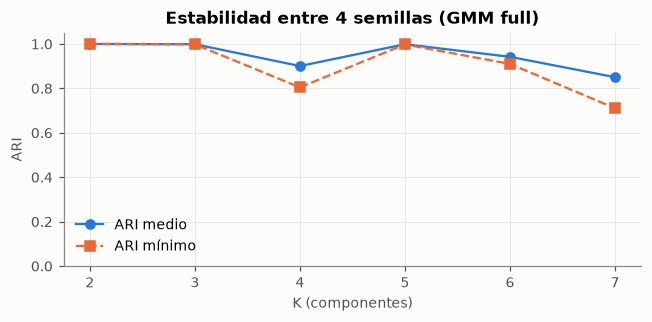

In [10]:
SEMILLAS = [0, 1, 2, 3]
filas, detalle = [], {}
t = time.perf_counter()
for k in range(2, 8):
    gs = [GaussianMixture(k, covariance_type='full', n_init=5, reg_covar=1e-4, max_iter=500,
                          random_state=s).fit(X) for s in SEMILLAS]
    labs = [g.predict(X) for g in gs]
    ll_s = np.array([g.score(X) for g in gs])        # log-verosimilitud media por paciente
    aris = [adjusted_rand_score(labs[i], labs[j]) for i in range(len(labs)) for j in range(i + 1, len(labs))]
    filas.append({'K': k, 'ARI_medio': np.mean(aris), 'ARI_mínimo': np.min(aris),
                  'rango_loglik_por_paciente': ll_s.max() - ll_s.min()})
    detalle[k] = pd.DataFrame({'semilla': SEMILLAS, 'loglik_por_paciente': ll_s,
                               'ARI_vs_mejor_semilla': [adjusted_rand_score(labs[int(ll_s.argmax())], l) for l in labs]})
estab = pd.DataFrame(filas).set_index('K')
print(f'Estabilidad: {time.perf_counter()-t:.0f} s')
tabla_sel = estab.join(res[res['cov'] == 'full'].set_index('K')[['BIC', 'peso_mín']])
tabla_sel['mejora_BIC'] = -tabla_sel['BIC'].diff()
display(tabla_sel.round(4))
print('Detalle para K = 4 (cada semilla con n_init=5):')
display(detalle[4].round(5))

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(estab.index, estab['ARI_medio'], 'o-', color=C[0], label='ARI medio')
ax.plot(estab.index, estab['ARI_mínimo'], 's--', color=C[1], label='ARI mínimo')
ax.set(title='Estabilidad entre 4 semillas (GMM full)', xlabel='K (componentes)', ylabel='ARI', ylim=(0, 1.05))
ax.legend(frameon=False); plt.tight_layout(); plt.show()

### 3.4 Decisión

In [11]:
K_FINAL, COV_FINAL = 4, 'full'
print(tabla_sel.loc[[3, 4, 5, 6]].round(3))

   ARI_medio  ARI_mínimo  rango_loglik_por_paciente         BIC  peso_mín  mejora_BIC
K                                                                                    
3      0.999       0.998                      0.000  355062.461     0.302    9623.698
4      0.901       0.805                      0.000  351358.979     0.195    3703.482
5      0.999       0.998                      0.000  349557.825     0.144    1801.154
6      0.942       0.910                      0.001  346286.269     0.086    3271.555


Elegimos **K = 4, covarianza `full`**:
- **Codo:** el BIC baja ~17 000 al pasar de 1 a 2 componentes, ~9 600 de 2 a 3 y ~3 700 de 3 a 4; a partir de ahí cada componente extra aporta menos de ~3 300 (y menos de 1 000 desde K = 8). Sobre una muestra de 20 000 pacientes, esas mejoras pequeñas son el costo de aproximar una densidad no gaussiana, no grupos nuevos.
- **Estabilidad:** K = 2, 3 y 5 dan prácticamente la misma partición con cualquier semilla (ARI ≈ 1). En **K = 4, tres de las cuatro semillas coinciden (ARI ≈ 0.99) y una cae en otro máximo local** (ARI ≈ 0.81) con una log-verosimilitud **casi idéntica** (diferencia ~0.0003 por paciente). Es decir, la superficie de verosimilitud es muy plana: hay dos formas casi igual de buenas de repartir los bordes entre grupos. Lo mitigamos usando `n_init=10` en el modelo final y verificando que coincide con la mejor solución. Desde K = 6 la inestabilidad crece (ARI mínimo 0.91 → 0.71 en K = 7).
- **Tamaño:** con K = 4 la componente más chica tiene ~20 % de los pacientes; no hay grupos diminutos (con K = 7 ya aparece uno de ~4 %).
- **Interpretabilidad:** las 4 componentes tienen una lectura clínica clara (sección 4). K = 5 es más estable, pero en la exploración vimos que solo divide uno de los grupos de estancia corta/media sin cambiar la historia del reingreso; preferimos el modelo más simple.

## 4. Modelo final (todo el dataset)
Para que el orden sea reproducible, renumeramos las componentes de mayor a menor peso.

In [12]:
t = time.perf_counter()
gmm = GaussianMixture(K_FINAL, covariance_type=COV_FINAL, n_init=10, reg_covar=1e-4, max_iter=500,
                      random_state=SEED).fit(X)
print(f'Ajuste: {time.perf_counter()-t:.1f} s | convergió: {gmm.converged_} | iteraciones: {gmm.n_iter_}')
print(f'log-verosimilitud media por paciente: {gmm.score(X):.5f} (mejor semilla de 3.3: {detalle[4]["loglik_por_paciente"].max():.5f})')

orden = np.argsort(-gmm.weights_)                   # componente original -> posición por peso
nuevo = np.empty(K_FINAL, int); nuevo[orden] = np.arange(K_FINAL)
proba = gmm.predict_proba(X)[:, orden]              # columnas ya reordenadas
lab = proba.argmax(axis=1)
pesos = gmm.weights_[orden]
medias_z = gmm.means_[orden]
d['comp'] = lab

perfil = pd.DataFrame(scaler.inverse_transform(medias_z), columns=FEAT)   # medias del modelo en escala original
perfil.insert(0, 'peso_%', pesos * 100)
perfil.insert(1, 'n_asignados', np.bincount(lab, minlength=K_FINAL))
extra = pd.DataFrame({
    '% num_procedures=0': (d['num_procedures'] == 0).groupby(lab).mean() * 100,
    '% con 9 diagnósticos': (d['number_diagnoses'] == 9).groupby(lab).mean() * 100,
    '% con visitas previas': d['tuvo_visitas_previas'].groupby(lab).mean() * 100,
})
display(perfil.join(extra).round(1))

Ajuste: 13.2 s | convergió: True | iteraciones: 31
log-verosimilitud media por paciente: -8.75755 (mejor semilla de 3.3: -8.75754)


,peso_%,n_asignados,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,age_num,n_meds_activos,% num_procedures=0,% con 9 diagnósticos,% con visitas previas
0,30.2,23181,4.9,46.3,1.0,16.9,9.0,69.2,1.2,43.2,96.7,31.8
1,29.6,20698,2.9,42.2,0.1,10.7,6.4,63.4,1.2,91.6,13.9,23.4
2,20.2,13880,2.5,34.3,2.7,14.0,6.2,62.0,1.0,2.0,14.1,22.3
3,20.0,12228,7.2,47.4,2.7,22.9,6.9,66.4,1.4,12.9,28.4,23.7


La tabla muestra las **medias de cada gaussiana** devueltas a la escala original (días, número de pruebas, años…) y, a la derecha, algunos porcentajes calculados con la asignación dura. Para comparar variables con unidades distintas miramos el mismo perfil en **z-scores** (cuántas desviaciones estándar por encima o debajo del promedio general está cada componente):

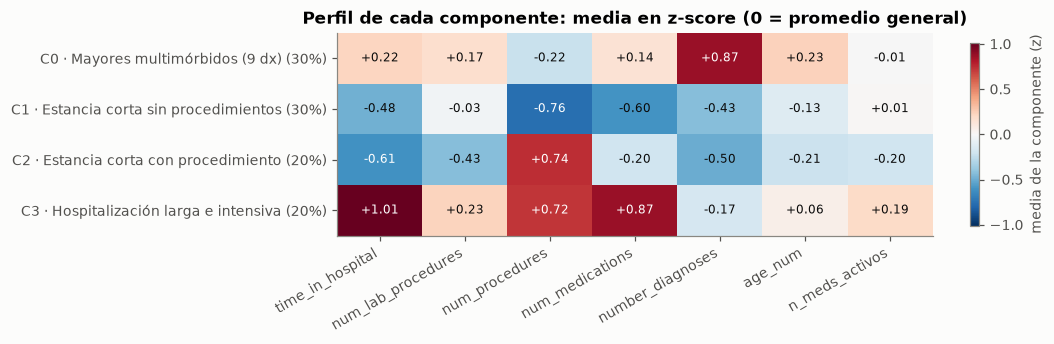

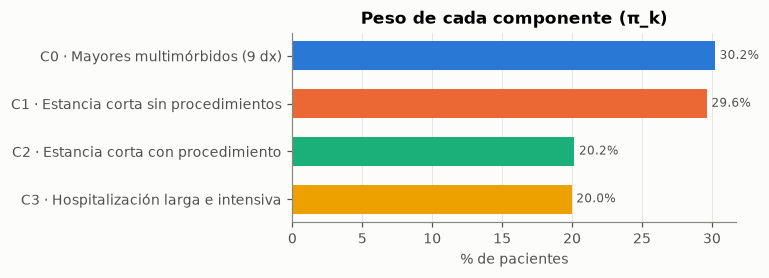

In [13]:
# Nombres descriptivos asignados a partir del perfil (reglas simples sobre las medias en z)
mz = pd.DataFrame(medias_z, columns=FEAT)
nombres = {}
nombres[int(mz['number_diagnoses'].idxmax())] = 'Mayores multimórbidos (9 dx)'
nombres[int(mz['time_in_hospital'].idxmax())] = 'Hospitalización larga e intensiva'
resto = [k for k in range(K_FINAL) if k not in nombres]
k_proc = max(resto, key=lambda k: mz.loc[k, 'num_procedures'])
nombres[k_proc] = 'Estancia corta con procedimiento'
for k in resto:
    if k != k_proc: nombres[k] = 'Estancia corta sin procedimientos'
ETQ = [f'C{k} · {nombres[k]}' for k in range(K_FINAL)]
d['comp_nombre'] = d['comp'].map(dict(enumerate(ETQ)))

fig, ax = plt.subplots(figsize=(10, 3.2))
lim = np.abs(mz.values).max()
im = ax.imshow(mz.values, cmap='RdBu_r', vmin=-lim, vmax=lim, aspect='auto')
ax.set_xticks(range(len(FEAT)), FEAT, rotation=30, ha='right'); ax.set_yticks(range(K_FINAL), [f'{e} ({p:.0%})' for e, p in zip(ETQ, pesos)])
for i in range(K_FINAL):
    for j in range(len(FEAT)):
        v = mz.values[i, j]
        ax.text(j, i, f'{v:+.2f}', ha='center', va='center', fontsize=8, color='white' if abs(v) > 0.6 * lim else '#0b0b0b')
ax.grid(False); fig.colorbar(im, ax=ax, shrink=0.9, label='media de la componente (z)')
ax.set_title('Perfil de cada componente: media en z-score (0 = promedio general)')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7, 2.6))
b = ax.barh(ETQ[::-1], pesos[::-1] * 100, color=C[:K_FINAL][::-1], height=0.6)
ax.bar_label(b, fmt='%.1f%%', padding=3, fontsize=8, color='#52514e')
ax.set(title='Peso de cada componente (π_k)', xlabel='% de pacientes'); ax.grid(axis='y', visible=False)
plt.tight_layout(); plt.show()

### 4.1 ¿Qué tan separados están los grupos?
Métricas sobre la **asignación dura** (cada paciente a su componente más probable), en el espacio escalado:
- **Silhouette** (−1 a 1; > 0.5 = grupos claros, ≈ 0 = grupos que se tocan). Se calcula sobre una muestra de 10 000 porque su costo es cuadrático.
- **Davies-Bouldin** (≥ 0; menor = mejor; valores > 2 indican grupos poco compactos o solapados).

Como referencia comparamos con **K-Means con el mismo K**.

In [14]:
idx_m = np.random.default_rng(1).choice(len(X), 10_000, replace=False)
km = KMeans(K_FINAL, n_init=10, random_state=SEED).fit(X)
metr = pd.DataFrame({
    'GMM full (K=4)': [silhouette_score(X[idx_m], lab[idx_m]), davies_bouldin_score(X, lab)],
    'K-Means (K=4)': [silhouette_score(X[idx_m], km.labels_[idx_m]), davies_bouldin_score(X, km.labels_)],
}, index=['silhouette (muestra 10k)', 'Davies-Bouldin'])
display(metr.round(3))
print(f'ARI entre GMM y K-Means: {adjusted_rand_score(lab, km.labels_):.3f}')

,GMM full (K=4),K-Means (K=4)
silhouette (muestra 10k),0.071,0.137
Davies-Bouldin,2.421,1.936


ARI entre GMM y K-Means: 0.184


K-Means siempre gana en silhouette y Davies-Bouldin porque **esas métricas miden exactamente lo que K-Means optimiza** (grupos esféricos compactos alrededor de un centro). La GMM corta el espacio de otra manera (elipses con tamaños distintos, una componente puede quedar “dentro” de otra más ancha), así que un silhouette bajo no significa que el modelo esté mal ajustado como densidad. Pero ambos números cuentan lo mismo que el PCA del EDA: **no hay grupos bien separados**; la GMM está segmentando un continuo.

### 4.2 Proyección PCA 2D

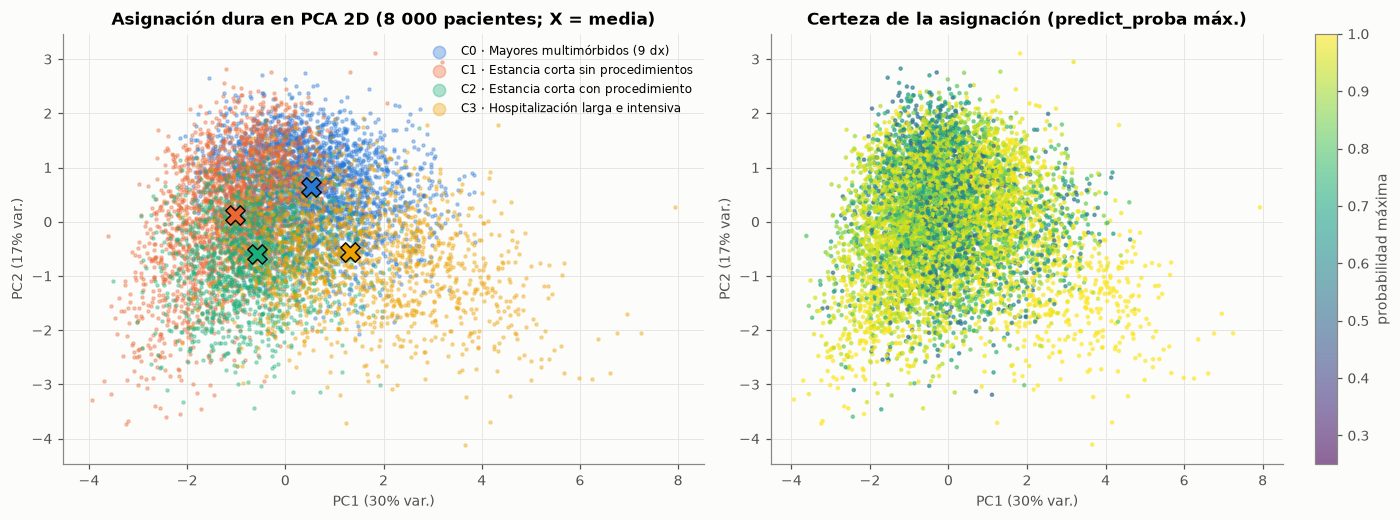

Cargas de las 2 primeras PCs:


,PC1,PC2
time_in_hospital,0.51,0.01
num_lab_procedures,0.36,0.03
num_procedures,0.33,-0.39
num_medications,0.56,-0.24
number_diagnoses,0.36,0.48
age_num,0.17,0.70
n_meds_activos,0.17,-0.27


In [15]:
pca = PCA(n_components=2, random_state=SEED).fit(X)
P2 = pca.transform(X)
M2 = pca.transform(medias_z)
idx_p = np.random.default_rng(2).choice(len(X), 8000, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for k in range(K_FINAL):
    m = idx_p[lab[idx_p] == k]
    axes[0].scatter(P2[m, 0], P2[m, 1], s=4, alpha=0.35, color=C[k], label=ETQ[k])
for k in range(K_FINAL):
    axes[0].scatter(*M2[k], s=160, marker='X', color=C[k], edgecolor='#0b0b0b', linewidth=1, zorder=5)
axes[0].set(title='Asignación dura en PCA 2D (8 000 pacientes; X = media)',
            xlabel=f'PC1 ({pca.explained_variance_ratio_[0]:.0%} var.)', ylabel=f'PC2 ({pca.explained_variance_ratio_[1]:.0%} var.)')
axes[0].legend(frameon=False, markerscale=4, fontsize=8, loc='upper right')

pmax = proba.max(axis=1)
sc_ = axes[1].scatter(P2[idx_p, 0], P2[idx_p, 1], c=pmax[idx_p], cmap='viridis', s=4, alpha=0.6, vmin=0.25, vmax=1)
fig.colorbar(sc_, ax=axes[1], label='probabilidad máxima')
axes[1].set(title='Certeza de la asignación (predict_proba máx.)',
            xlabel=f'PC1 ({pca.explained_variance_ratio_[0]:.0%} var.)', ylabel=f'PC2 ({pca.explained_variance_ratio_[1]:.0%} var.)')
plt.tight_layout(); plt.show()
print('Cargas de las 2 primeras PCs:')
display(pd.DataFrame(pca.components_.T, index=FEAT, columns=['PC1', 'PC2']).round(2))

En 2D los grupos se **superponen** (recordemos que PCA 2D solo muestra una parte de la varianza de 7 variables; parte de la separación ocurre en otras direcciones, como la de `number_diagnoses`). El panel derecho muestra dónde el modelo duda: las **fronteras** entre componentes y el centro de la nube tienen probabilidades máximas bajas.

## 5. Asignación blanda: ¿qué tan seguros estamos?
`predict_proba` da, para cada paciente, las responsabilidades $r_{ik}$ (suman 1). La **probabilidad máxima** indica la certeza de la asignación: con 4 componentes el mínimo posible es 0.25 (total indecisión).

max prob < 0.5: 1.6% | max prob < 0.7: 21.3% | max prob < 0.9: 47.1%


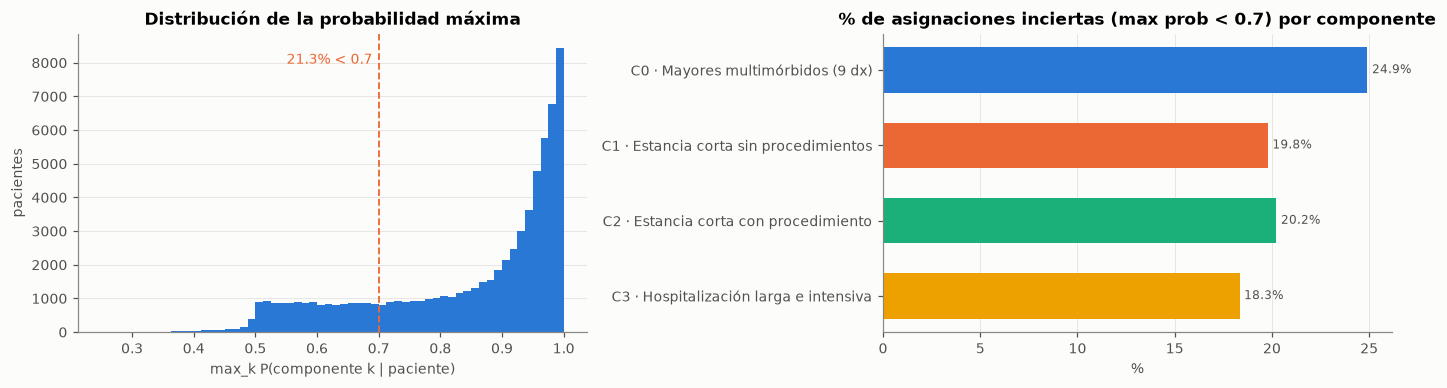

Pacientes inciertos: componente asignada (fila) vs. segunda opción (columna)


segunda más probable,0,1,2,3
componente asignada,,,,
0,0,4001,801,973
1,2553,0,1024,519
2,567,763,0,1478
3,753,387,1102,0


In [16]:
assert np.allclose(proba.sum(axis=1), 1)
entropia = -(proba * np.log(np.clip(proba, 1e-300, None))).sum(axis=1)
umbrales = [0.5, 0.7, 0.9]
print(' | '.join(f'max prob < {u}: {(pmax < u).mean()*100:.1f}%' for u in umbrales))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
axes[0].hist(pmax, bins=np.linspace(0.25, 1, 61), color=C[0])
axes[0].axvline(0.7, color=C[1], ls='--', lw=1.2)
axes[0].text(0.69, axes[0].get_ylim()[1] * 0.9, f'{(pmax < 0.7).mean()*100:.1f}% < 0.7', ha='right', color=C[1])
axes[0].set(title='Distribución de la probabilidad máxima', xlabel='max_k P(componente k | paciente)', ylabel='pacientes')
axes[0].grid(axis='x', visible=False)

incierto = pd.Series(pmax < 0.7).groupby(lab).mean() * 100
b = axes[1].barh(ETQ[::-1], incierto.values[::-1], color=C[:K_FINAL][::-1], height=0.6)
axes[1].bar_label(b, fmt='%.1f%%', padding=3, fontsize=8, color='#52514e')
axes[1].set(title='% de asignaciones inciertas (max prob < 0.7) por componente', xlabel='%'); axes[1].grid(axis='y', visible=False)
plt.tight_layout(); plt.show()

# ¿Entre qué pares de componentes duda el modelo?
seg = np.argsort(-proba, axis=1)[:, 1]
dudas = pd.crosstab(pd.Series(lab, name='componente asignada')[pmax < 0.7],
                    pd.Series(seg, name='segunda más probable')[pmax < 0.7])
print('Pacientes inciertos: componente asignada (fila) vs. segunda opción (columna)')
display(dudas)

**Lectura:** la mayoría de las asignaciones son seguras (el pico está cerca de 1), pero **~21 % de los pacientes tiene probabilidad máxima < 0.7** y ~47 % < 0.9; casi nadie baja de 0.5 (1.6 %), o sea, las dudas son casi siempre **entre dos componentes vecinas**, no entre las cuatro. La duda más frecuente es **C0 ↔ C1** (multimórbidos vs estancia corta sin procedimientos): pacientes con estancia corta y 8–9 diagnósticos quedan a medio camino. La meseta de pacientes entre 0.5 y 0.7 es otra señal de que los grupos **se superponen**: con clusters bien separados casi todo estaría por encima de 0.9. Esta información se pierde si solo usamos `predict` (asignación dura).

## 6. Interpretación clínica: cruce con reingreso y categóricas
El modelo **no vio** `readmitted`; ahora lo usamos para ver si los perfiles se asocian al reingreso. Referencia global: ~9 % reingresa en <30 días.

readmitted,<30,>30,NO,n
comp_nombre,,,,
C0 · Mayores multimórbidos (9 dx),10.2,35.6,54.2,23181
C1 · Estancia corta sin procedimientos,7.9,31.5,60.6,20698
C2 · Estancia corta con procedimiento,6.8,26.6,66.5,13880
C3 · Hospitalización larga e intensiva,10.9,30.7,58.4,12228


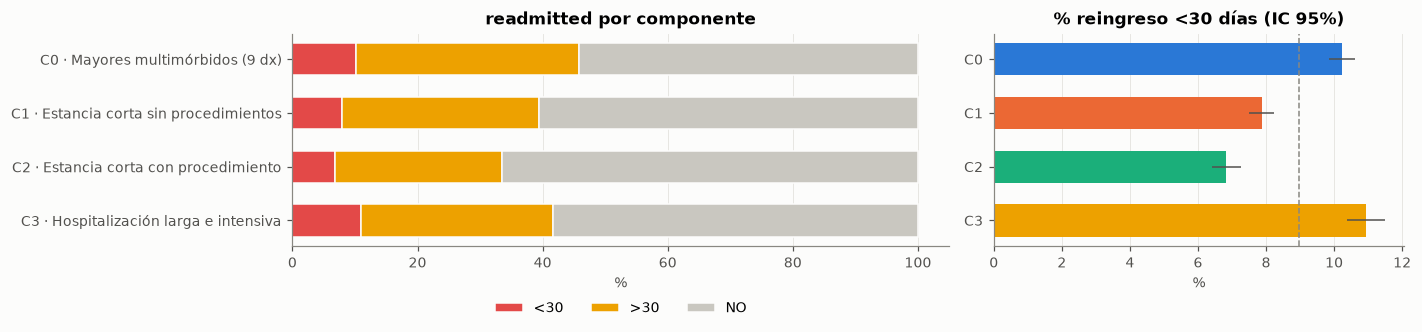

In [17]:
tab_r = pd.crosstab(d['comp_nombre'], d['readmitted'], normalize='index')[['<30', '>30', 'NO']] * 100
tab_r['n'] = d['comp_nombre'].value_counts()
display(tab_r.round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.2), gridspec_kw={'width_ratios': [1.6, 1]})
izq = np.zeros(K_FINAL)
for cat, col in zip(['<30', '>30', 'NO'], [C[7], C[3], '#c9c7c0']):
    axes[0].barh(tab_r.index, tab_r[cat], left=izq, color=col, label=cat, height=0.6, edgecolor='#fcfcfb')
    izq += tab_r[cat].values
axes[0].invert_yaxis(); axes[0].legend(frameon=False, ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.2))
axes[0].set(title='readmitted por componente', xlabel='%'); axes[0].grid(axis='y', visible=False)

p30 = d.groupby('comp')['readmitted_30'].agg(['mean', 'count'])
err = 1.96 * np.sqrt(p30['mean'] * (1 - p30['mean']) / p30['count']) * 100
axes[1].barh(ETQ, p30['mean'] * 100, xerr=err, color=C[:K_FINAL], height=0.6, error_kw=dict(ecolor='#52514e', lw=1))
axes[1].axvline(d['readmitted_30'].mean() * 100, color=MUTED, ls='--', lw=1)
axes[1].invert_yaxis(); axes[1].set_yticks(range(K_FINAL), [f'C{k}' for k in range(K_FINAL)])
axes[1].set(title='% reingreso <30 días (IC 95%)', xlabel='%'); axes[1].grid(axis='y', visible=False)
plt.tight_layout(); plt.show()

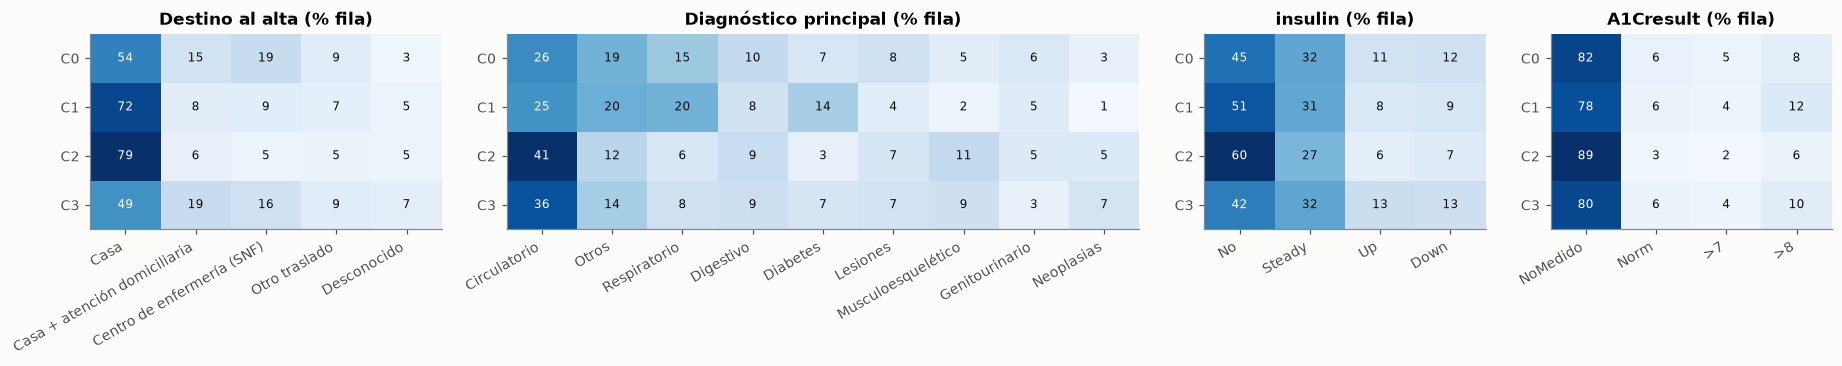

Leyenda: C0 · Mayores multimórbidos (9 dx) | C1 · Estancia corta sin procedimientos | C2 · Estancia corta con procedimiento | C3 · Hospitalización larga e intensiva


In [18]:
def alta(s):
    if s == 'Discharged to home': return 'Casa'
    if 'home health' in s: return 'Casa + atención domiciliaria'
    if 'SNF' in s: return 'Centro de enfermería (SNF)'
    if s == 'Desconocido': return 'Desconocido'
    return 'Otro traslado'
d['alta'] = d['discharge_disposition_id'].map(alta)

def heat(ax, tabla, titulo):
    im = ax.imshow(tabla.values, cmap='Blues', aspect='auto', vmin=0)
    ax.set_xticks(range(tabla.shape[1]), tabla.columns, rotation=30, ha='right')
    ax.set_yticks(range(tabla.shape[0]), [f'C{k}' for k in range(tabla.shape[0])])
    for i in range(tabla.shape[0]):
        for j in range(tabla.shape[1]):
            v = tabla.values[i, j]
            ax.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=8,
                    color='white' if v > 0.6 * tabla.values.max() else '#0b0b0b')
    ax.grid(False); ax.set_title(titulo)

t_alta = pd.crosstab(d['comp'], d['alta'], normalize='index')[['Casa', 'Casa + atención domiciliaria', 'Centro de enfermería (SNF)', 'Otro traslado', 'Desconocido']] * 100
t_diag = pd.crosstab(d['comp'], d['diag_1'], normalize='index') * 100
t_diag = t_diag[t_diag.mean().sort_values(ascending=False).index]
t_diag = t_diag.loc[:, t_diag.mean() >= 0.5]          # quita categorías casi vacías
t_ins = pd.crosstab(d['comp'], d['insulin'], normalize='index')[['No', 'Steady', 'Up', 'Down']] * 100
t_a1c = pd.crosstab(d['comp'], d['A1Cresult'], normalize='index')[['NoMedido', 'Norm', '>7', '>8']] * 100

fig, axes = plt.subplots(1, 4, figsize=(17, 3.4), gridspec_kw={'width_ratios': [5, 9, 4, 4]})
heat(axes[0], t_alta, 'Destino al alta (% fila)')
heat(axes[1], t_diag, 'Diagnóstico principal (% fila)')
heat(axes[2], t_ins, 'insulin (% fila)')
heat(axes[3], t_a1c, 'A1Cresult (% fila)')
plt.tight_layout(); plt.show()
print('Leyenda:', ' | '.join(ETQ))

**Interpretación de cada componente** (nombres asignados a partir del perfil):

- **C0 · Mayores multimórbidos (9 dx), 30 %:** el rasgo que la define es `number_diagnoses` (97 % tiene exactamente 9, el tope del sistema) y son algo mayores (69 años de media vs 66 global). Estancia y medicamentos cerca del promedio. Es el grupo con **más altas a centros de enfermería (SNF, 19 %)** y con **más reingreso >30 días (35.6 %)**; también tiene más pacientes con visitas previas (32 % vs ~23 % en el resto). Reingreso <30: **10.2 %**. Ojo: parte de este grupo refleja la **época del registro** (el EDA mostró que el tope de 9 diagnósticos es más frecuente en los IDs recientes).
- **C1 · Estancia corta sin procedimientos, 30 %:** ~3 días, casi nunca procedimientos (92 % con 0), pocos medicamentos. Más diagnósticos principales **respiratorios (20 %) y de diabetes (14 %)**: hospitalizaciones médicas breves. 72 % se va a casa. Reingreso <30: **7.9 %**.
- **C2 · Estancia corta con procedimiento, 20 %:** ~2.5 días pero ~2.7 procedimientos, menos laboratorio, pacientes algo más jóvenes; **41 % circulatorio** y 11 % musculoesquelético (típico de intervenciones programadas: cateterismos, cirugías). **79 % alta a casa**, 60 % sin insulina, 89 % sin HbA1c medida. Es el grupo de **menor riesgo: 6.8 %** reingresa en <30 días.
- **C3 · Hospitalización larga e intensiva, 20 %:** ~7 días, ~23 medicamentos, ~2.7 procedimientos, más antidiabéticos activos y más insulina ajustada (Up/Down 26 %). Solo 49 % se va a casa (19 % con atención domiciliaria, 16 % a SNF). Es el grupo de **mayor riesgo: 10.9 %** en <30 días.

Los intervalos de confianza del 95 % no se solapan entre los grupos de riesgo alto (C0, C3) y bajo (C1, C2), así que las diferencias no son ruido. Pero el rango es **modesto (6.8 % a 10.9 % frente a 9.0 % global)**: los perfiles de hospitalización se asocian con el reingreso, no lo determinan.

In [19]:
# Resumen final por componente: todo junto
resumen_comp = pd.DataFrame({
    'nombre': [nombres[k] for k in range(K_FINAL)],
    'peso_%': pesos * 100,
    'estancia_días': perfil['time_in_hospital'].values,
    'procedimientos': perfil['num_procedures'].values,
    'medicamentos': perfil['num_medications'].values,
    'diagnósticos': perfil['number_diagnoses'].values,
    'edad': perfil['age_num'].values,
    '% alta a casa': t_alta['Casa'].values,
    '% visitas previas': extra['% con visitas previas'].values,
    '% <30': p30['mean'].values * 100,
    '% >30': (d['readmitted'] == '>30').groupby(d['comp']).mean().values * 100,
    '% incierto (p<0.7)': incierto.values,
}, index=[f'C{k}' for k in range(K_FINAL)])
display(resumen_comp.round(1))

,nombre,peso_%,estancia_días,procedimientos,medicamentos,diagnósticos,edad,% alta a casa,% visitas previas,% <30,% >30,% incierto (p<0.7)
C0,Mayores multimórbidos (9 dx),30.2,4.9,1.0,16.9,9.0,69.2,54.1,31.8,10.2,35.6,24.9
C1,Estancia corta sin procedimientos,29.6,2.9,0.1,10.7,6.4,63.4,71.7,23.4,7.9,31.5,19.8
C2,Estancia corta con procedimiento,20.2,2.5,2.7,14.0,6.2,62.0,78.9,22.3,6.8,26.6,20.2
C3,Hospitalización larga e intensiva,20.0,7.2,2.7,22.9,6.9,66.4,49.0,23.7,10.9,30.7,18.3


## 7. Log-verosimilitud por paciente como detector de atípicos
`score_samples(X)` devuelve $\log p(x_i)$, la densidad de la mezcla en cada paciente. Los valores más bajos son pacientes “raros” para el modelo (combinaciones poco frecuentes). ¿El 2 % menos probable reingresa más?

,n,pct_menos30,pct_mas30
resto (98%),68587,8.99,31.83
atípicos (2% menos probable),1400,8.43,28.29


Perfil medio de los atípicos vs el resto (escala original):


atipico,resto,atípicos
time_in_hospital,4.20,8.02
num_lab_procedures,42.84,44.60
num_procedures,1.39,2.94
num_medications,15.44,26.70
number_diagnoses,7.23,6.86
age_num,65.65,55.29
n_meds_activos,1.18,1.84
tuvo_visitas_previas,0.26,0.22


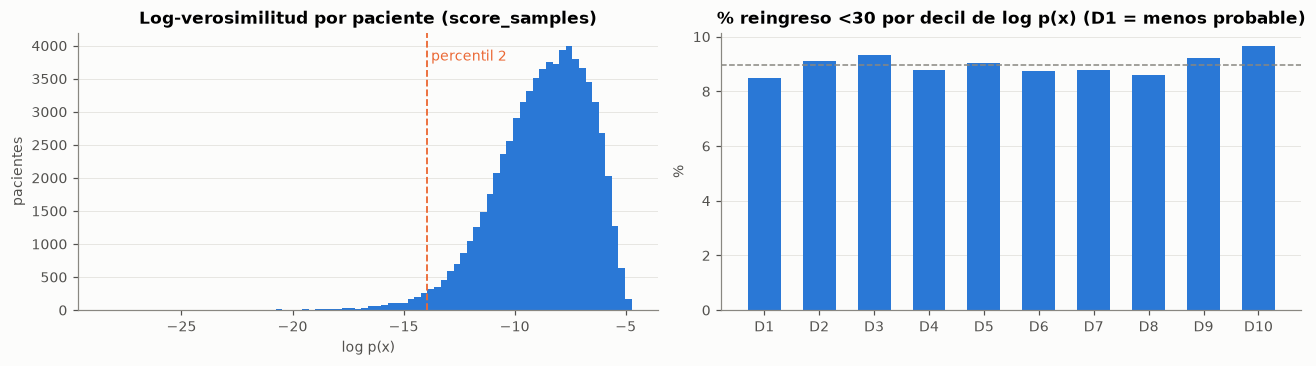

Tiempo total del notebook: 5.7 min


In [20]:
ll = gmm.score_samples(X)
corte = np.quantile(ll, 0.02)
d['atipico'] = ll < corte
comp_at = d.groupby('atipico').agg(n=('readmitted_30', 'size'), pct_menos30=('readmitted_30', 'mean'),
                                     pct_mas30=('readmitted', lambda s: (s == '>30').mean()))
comp_at[['pct_menos30', 'pct_mas30']] *= 100
comp_at.index = ['resto (98%)', 'atípicos (2% menos probable)']
display(comp_at.round(2))
print('Perfil medio de los atípicos vs el resto (escala original):')
display(d.groupby('atipico')[FEAT + ['tuvo_visitas_previas']].mean().T.rename(columns={False: 'resto', True: 'atípicos'}).round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
axes[0].hist(ll, bins=80, color=C[0])
axes[0].axvline(corte, color=C[1], ls='--', lw=1.2); axes[0].text(corte, axes[0].get_ylim()[1] * 0.9, ' percentil 2', color=C[1])
axes[0].set(title='Log-verosimilitud por paciente (score_samples)', xlabel='log p(x)', ylabel='pacientes'); axes[0].grid(axis='x', visible=False)
dec = pd.qcut(ll, 10, labels=[f'D{i}' for i in range(1, 11)])
r_dec = d.groupby(dec, observed=True)['readmitted_30'].mean() * 100
axes[1].bar(r_dec.index.astype(str), r_dec.values, color=C[0], width=0.6)
axes[1].axhline(d['readmitted_30'].mean() * 100, color=MUTED, ls='--', lw=1)
axes[1].set(title='% reingreso <30 por decil de log p(x) (D1 = menos probable)', ylabel='%'); axes[1].grid(axis='x', visible=False)
plt.tight_layout(); plt.show()
print(f'Tiempo total del notebook: {(time.perf_counter()-T0)/60:.1f} min')

**Respuesta: no.** El 2 % de pacientes menos probables para el modelo reingresa en <30 días un **8.4 %**, algo *menos* que el resto (9.0 %), y el % de reingreso es prácticamente plano en los 10 deciles de $\log p(x)$ (≈ 8.5–9.7 %). Los “atípicos” son sobre todo pacientes más jóvenes (55 vs 66 años) con estancias largas (8 días) y muchos medicamentos (27): son raros en el espacio de features, pero **rareza estadística ≠ riesgo clínico**. La densidad de la GMM sirve para detectar registros inusuales (p. ej. para revisar calidad de datos), no como predictor de reingreso.

## 8. Resumen de la primera versión

**Preparación**
- Usamos 7 variables de la hospitalización actual (`time_in_hospital`, `num_lab_procedures`, `num_procedures`, `num_medications`, `number_diagnoses`, `age_num`, `n_meds_activos`), con **jitter** $U(-0.5, 0.5)$ por escalón y `StandardScaler`, sobre los **69 987 pacientes**; la grilla de BIC se hizo sobre una muestra de 20 000.
- **Incluir las visitas previas rompe el modelo:** la componente principal (74 %) pasa a ser “0 visitas” con desviación estándar 0.01 (el piso de `reg_covar`) y el BIC llega a valores negativos. Las dejamos solo para interpretar.
- **Sin jitter, la discretez también rompe el BIC:** desde K = 3 aparecen componentes aplastadas sobre un valor entero (sd 0.01) y la curva de BIC baja a saltos y sin codo. Con jitter la curva se vuelve suave.

**Selección**
- `full` gana a `diag`, `tied` y `spherical` en todo K ≥ 2 (las componentes necesitan elipses propias con correlaciones).
- El BIC **sigue bajando hasta K = 12** porque los datos no son gaussianos (asimetría, topes); no existe un “K verdadero”. Elegimos **K = 4** por el codo (mejoras de 17 200 → 9 600 → 3 700 y luego ≤ 3 300), tamaño mínimo (~20 %) e interpretabilidad. La estabilidad es buena pero no perfecta: 3 de 4 semillas dan la misma partición (ARI ≈ 0.99) y otra llega a un óptimo alternativo casi igual de verosímil (ARI ≈ 0.81).

**Los 4 perfiles** (pesos 30 / 30 / 20 / 20 %)

| Componente | Rasgo principal | % reingreso <30 |
|---|---|---|
| C0 · Mayores multimórbidos (9 dx) | 9 diagnósticos, ~69 años, más altas a SNF, más reingreso >30 (35.6 %) | 10.2 % |
| C1 · Estancia corta sin procedimientos | ~3 días, sin procedimientos, más respiratorio/diabetes | 7.9 % |
| C2 · Estancia corta con procedimiento | ~2.5 días con ~2.7 procedimientos, 41 % circulatorio, 79 % a casa | 6.8 % |
| C3 · Hospitalización larga e intensiva | ~7 días, ~23 medicamentos, solo 49 % a casa | 10.9 % |

**¿Qué tan buenos son los grupos?**
- **Separación pobre:** silhouette 0.07 y Davies-Bouldin 2.42 (K-Means con K = 4: 0.14 y 1.94, y solo coincide con la GMM en ARI 0.18). En PCA 2D las componentes se superponen.
- **Asignación blanda:** 21 % de los pacientes tiene probabilidad máxima < 0.7 (dudas casi siempre entre dos componentes vecinas, sobre todo C0 ↔ C1).
- **Relación con el reingreso:** real pero modesta, de **6.8 % a 10.9 %** frente a 9.0 % global. La GMM no es un clasificador de riesgo; sus probabilidades (`predict_proba`) sí pueden servir como **features resumidas** para un modelo supervisado.
- **Atípicos por densidad:** el 2 % menos probable **no** reingresa más (8.4 % vs 9.0 %).

**Limitaciones**
- La GMM está **partiendo un continuo**, no descubriendo tipos naturales de pacientes: los nombres de las componentes describen regiones del espacio, no enfermedades.
- El jitter agrega aleatoriedad (semilla fija = reproducible); C0 depende del tope de 9 diagnósticos, que es en parte un efecto de la época del registro.
- Las categóricas (diagnóstico, destino al alta, insulina) no entraron al modelo; solo se usaron para interpretar. Un modelo de mezcla para datos mixtos (p. ej. clases latentes) o una segmentación con K-Prototypes serían alternativas para incluirlas.

## 9. Revisión crítica: estabilidad, elección de K y validación externa

Al revisar la metodología encontramos cuatro puntos débiles en la primera versión:

1. **El jitter agrega aleatoriedad que no se evaluó.** Solo variamos la semilla de la GMM; nunca la del ruido. Si los grupos cambian según el ruido que inventamos, el resultado depende de un detalle arbitrario.
2. **K = 4 se eligió por el codo del BIC**, que no tiene mínimo. Existe un criterio pensado para clustering: el **ICL** (*Integrated Completed Likelihood*, Biernacki, Celeux y Govaert, 2000). Es el BIC más una penalización por **entropía**: castiga los modelos cuyas componentes se solapan, es decir, donde muchos pacientes quedan a medio camino entre dos grupos. Se elige el K con **menor** ICL.
3. **Silhouette y Davies-Bouldin** miden separación geométrica, no si el modelo de mezcla es bueno.
4. **La validación externa** (tasa de reingreso por grupo) no tenía **intervalos de confianza** ni una **línea base**: ¿los grupos de la GMM dicen más sobre el reingreso que dividir a los pacientes por una sola variable?

Plan, siempre con **GaussianMixture**:
- 9.1 Estabilidad frente al jitter y elección de K con ICL.
- 9.2 **GMM de consenso**: ajustar la misma GMM sobre varias versiones con distinto jitter y promediar las probabilidades.
- 9.3 Perfil de los grupos del consenso.
- 9.4 Validación externa con intervalos de confianza y línea base.

### 9.1 Estabilidad frente al jitter y elección de K

Para cada K de 2 a 8 ajustamos la GMM (`full`) sobre **5 versiones del mismo dataset con distinto jitter** (muestra de 20 000 pacientes, la misma de la sección 3). Medimos:
- **ICL** medio (menor es mejor);
- **ARI entre jitters:** qué tanto coinciden las particiones obtenidas con distinto ruido (1 = idénticas);
- **probabilidad máxima media:** qué tan seguras son las asignaciones;
- **peso mínimo:** tamaño del grupo más chico.

Tiempo: 60 s


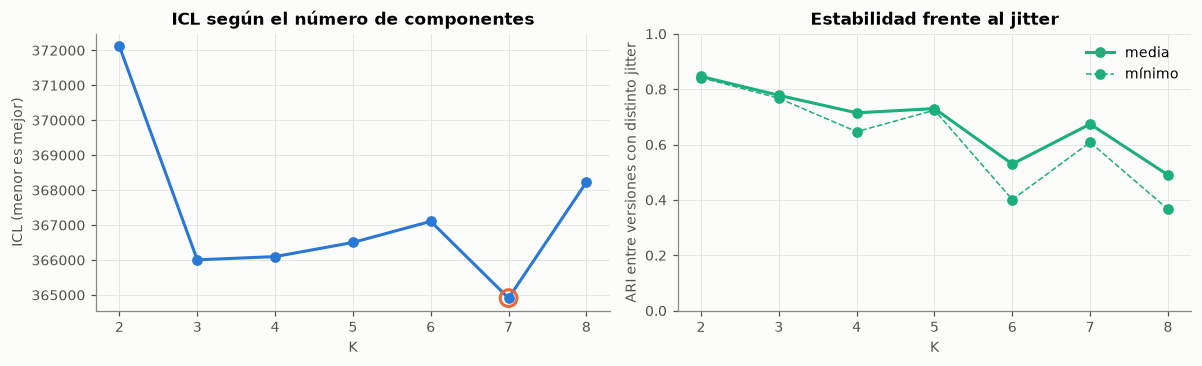

,ICL,ICL desv. entre jitters,ICL mín.,ICL máx.,ARI entre jitters (media),ARI mínimo,prob. máx. media,peso mínimo
K,,,,,,,,
2,372111.392,136.029,371879.374,372250.394,0.846,0.842,0.926,0.494
3,366007.178,105.384,365898.681,366183.626,0.778,0.767,0.885,0.305
4,366100.099,243.589,365885.029,366576.704,0.715,0.647,0.853,0.190
5,366504.092,142.613,366329.296,366715.947,0.730,0.724,0.835,0.144
6,367108.381,1982.777,365241.657,369633.971,0.530,0.401,0.813,0.106
7,364912.477,2072.469,363186.581,367639.405,0.674,0.608,0.816,0.052
8,368226.958,1613.101,365082.128,369616.071,0.490,0.366,0.784,0.054


In [21]:
from itertools import combinations
from scipy.optimize import linear_sum_assignment
from scipy.stats import chi2_contingency
INK = '#52514e'

def jitter_escalado(datos, semilla):
    r = np.random.default_rng(semilla)
    M = datos[FEAT].astype(float).copy()
    for c in FEAT:
        M[c] += r.uniform(-0.5, 0.5, len(M)) * PASO[c]
    return StandardScaler().fit_transform(M)

def icl(g, X_):
    p = g.predict_proba(X_)
    return g.bic(X_) + 2 * -(p * np.log(np.clip(p, 1e-300, 1))).sum()

muestra = d.iloc[idx_s]
X_jits = [jitter_escalado(muestra, j) for j in range(5)]
filas = []
t = time.perf_counter()
for K in range(2, 9):
    labs, icls, pmax, wmin = [], [], [], []
    for Xj in X_jits:
        g = GaussianMixture(K, covariance_type='full', n_init=3, reg_covar=1e-4, random_state=0).fit(Xj)
        labs.append(g.predict(Xj)); icls.append(icl(g, Xj)); pmax.append(g.predict_proba(Xj).max(1).mean()); wmin.append(g.weights_.min())
    aris = [adjusted_rand_score(a, b) for a, b in combinations(labs, 2)]
    filas.append({'K': K, 'ICL': np.mean(icls), 'ICL desv. entre jitters': np.std(icls), 'ICL mín.': np.min(icls), 'ICL máx.': np.max(icls),
                  'ARI entre jitters (media)': np.mean(aris), 'ARI mínimo': np.min(aris),
                  'prob. máx. media': np.mean(pmax), 'peso mínimo': np.mean(wmin)})
sel = pd.DataFrame(filas).set_index('K')
print(f'Tiempo: {time.perf_counter() - t:.0f} s')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot(sel.index, sel['ICL'], marker='o', color=C[0], lw=2)
axes[0].scatter([sel['ICL'].idxmin()], [sel['ICL'].min()], s=120, facecolors='none', edgecolors=C[1], lw=2, zorder=3)
axes[0].set_xlabel('K'); axes[0].set_ylabel('ICL (menor es mejor)'); axes[0].set_title('ICL según el número de componentes')
axes[1].plot(sel.index, sel['ARI entre jitters (media)'], marker='o', color=C[2], lw=2, label='media')
axes[1].plot(sel.index, sel['ARI mínimo'], marker='o', color=C[2], lw=1, ls='--', label='mínimo')
axes[1].set_ylim(0, 1); axes[1].set_xlabel('K'); axes[1].set_ylabel('ARI entre versiones con distinto jitter')
axes[1].set_title('Estabilidad frente al jitter'); axes[1].legend(frameon=False)
plt.tight_layout(); plt.show()
sel.round(3)

- **El ICL no señala un K claro.** En promedio su mínimo está en K = 7, pero ese valor **no es robusto**: el ICL de K = 7 cambia mucho según la realización del jitter (desviación ≈ 2 070; va de 363 187 a 367 639), un rango que abarca los valores de K = 3 y K = 4 (≈ 366 000, con variación de solo 100–250). La diferencia entre K = 3 y K = 4 es menor que la variación entre réplicas. **Que el “mejor” K dependa del ruido agregado es otra señal de que los datos no tienen un número natural de grupos.**
- **K = 7 tampoco es una buena opción por tamaño y estabilidad:** su componente más chica tiene solo el 5 % de los pacientes y es menos estable (ARI mínimo 0.61).
- **La estabilidad frente al jitter tiende a bajar al aumentar K, pero no de forma monótona:** 0.85 con K = 2, 0.78 con K = 3, **0.72 con K = 4** (mínimo 0.65) y 0.73 con K = 5 (mínimo 0.72). Es decir, **K = 5 es algo más estable que K = 4**.
- **Decisión:** mantenemos **K = 4** por **interpretabilidad**, no por estabilidad. Está empatado en ICL con K = 3, sus componentes tienen al menos el 18–19 % de los pacientes y separa perfiles clínicamente distintos (la estancia corta *con* procedimientos de la estancia corta *sin* procedimientos); K = 5 solo subdivide uno de los grupos de estancia corta sin cambiar la historia del reingreso (sección 3.4). Su estabilidad moderada la corregimos con el consenso de la sección siguiente.

### 9.2 GMM de consenso

Para que el resultado no dependa de **una** realización del ruido, ajustamos la GMM (K = 4, `full`) sobre **10 versiones del dataset completo con distinto jitter** y **promediamos las probabilidades** de cada paciente. Como la numeración de las componentes es arbitraria en cada ajuste (la “componente 1” de un ajuste puede ser la “componente 3” de otro), antes de promediar las **alineamos** con el algoritmo húngaro (`linear_sum_assignment`), que empareja cada componente con la que más se le parece en el primer ajuste. Es la misma idea que promediar varias imputaciones: el ruido se cancela y queda lo que se repite.

Para comprobar que funciona, hacemos **dos consensos independientes** (semillas 0–9 y 100–109) y medimos cuánto coinciden.

In [22]:
K_FINAL = 4

def gmm_consenso(semillas, ref=None):
    probs = []
    for j in semillas:
        Xj = jitter_escalado(d, j)
        g = GaussianMixture(K_FINAL, covariance_type='full', n_init=3, reg_covar=1e-4, random_state=0).fit(Xj)
        p = g.predict_proba(Xj)
        if ref is None:
            ref = p
        _, orden = linear_sum_assignment(-(ref.T @ p))     # alinear componentes con la referencia
        probs.append(p[:, orden])
    return np.mean(probs, axis=0), probs

t = time.perf_counter()
P_A, ajustes_A = gmm_consenso(range(10))
P_B, ajustes_B = gmm_consenso(range(100, 110), ref=P_A)
print(f'Tiempo: {time.perf_counter() - t:.0f} s')

lab_cons = P_A.argmax(1)
ari_ind = [adjusted_rand_score(a.argmax(1), b.argmax(1)) for a, b in combinations(ajustes_A, 2)]
estab = pd.Series({'ARI entre ajustes individuales (media)': np.mean(ari_ind),
                   'ARI entre ajustes individuales (mínimo)': np.min(ari_ind),
                   'ARI entre dos consensos independientes': adjusted_rand_score(lab_cons, P_B.argmax(1))}, name='valor')
display(estab.round(3).to_frame())

jac = pd.DataFrame({
    'peso': [(lab_cons == k).mean() for k in range(K_FINAL)],
    # ajustes individuales INDEPENDIENTES del consenso (semillas 100-109, no usadas para construirlo)
    'Jaccard medio (ajuste independiente vs consenso)': [np.mean([((lab_cons == k) & (a.argmax(1) == k)).sum() /
        ((lab_cons == k) | (a.argmax(1) == k)).sum() for a in ajustes_B]) for k in range(K_FINAL)],
    'Jaccard mínimo': [np.min([((lab_cons == k) & (a.argmax(1) == k)).sum() /
        ((lab_cons == k) | (a.argmax(1) == k)).sum() for a in ajustes_B]) for k in range(K_FINAL)],
    'prob. máx. media': [P_A.max(1)[lab_cons == k].mean() for k in range(K_FINAL)],
}, index=[f'comp {k}' for k in range(K_FINAL)])
print(f'Pacientes con asignación incierta (prob. máx. < 0.7): {(P_A.max(1) < 0.7).mean():.1%}')
jac.round(3)

Tiempo: 91 s


,valor
ARI entre ajustes individuales (media),0.708
ARI entre ajustes individuales (mínimo),0.674
ARI entre dos consensos independientes,0.876


Pacientes con asignación incierta (prob. máx. < 0.7): 26.4%


,peso,Jaccard medio (ajuste independiente vs consenso),Jaccard mínimo,prob. máx. media
comp 0,0.284,0.807,0.799,0.840
comp 1,0.331,0.843,0.827,0.805
comp 2,0.209,0.821,0.758,0.798
comp 3,0.176,0.854,0.770,0.853


- **El consenso resuelve la inestabilidad:** dos consensos hechos con semillas de jitter distintas coinciden con **ARI = 0.88**, contra 0.71 entre ajustes individuales. El resultado ya no depende de una realización particular del ruido.
- **Cada componente es estable** según el criterio de Hennig: su Jaccard medio con 10 ajustes **independientes** (semillas que no se usaron para construir el consenso) va de **0.81 a 0.85** (mínimos individuales 0.76–0.83; ≥ 0.75 estable, ≥ 0.85 muy estable).
- **Las asignaciones siguen siendo difusas:** el **26 %** de los pacientes tiene una probabilidad máxima menor a 0.7 (en la primera versión, 21 %). Al promediar, los pacientes que caían en grupos distintos según el jitter quedan con probabilidades repartidas, lo cual es más honesto: esos pacientes están de verdad en la frontera entre dos perfiles.

### 9.3 Perfil de los grupos del consenso

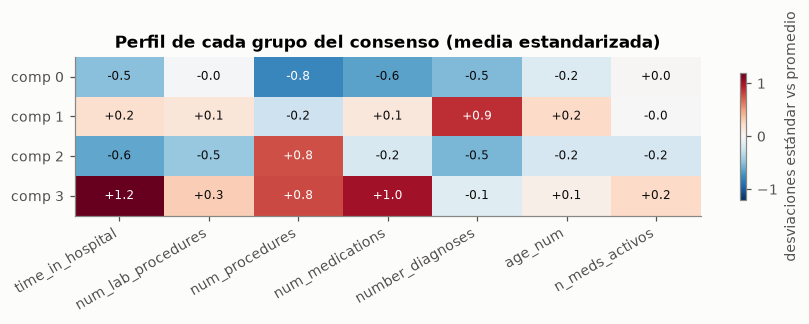

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,age_num,n_meds_activos,% pacientes,% con 9 diagnósticos,% sin procedimientos,% con visitas previas
comp 0,2.80,42.37,0.05,10.38,6.16,62.86,1.20,28.35,12.76,94.62,23.44
comp 1,4.82,45.85,1.00,16.76,8.99,69.16,1.18,33.07,98.77,44.02,31.84
comp 2,2.45,33.89,2.78,14.11,6.13,62.17,1.00,20.95,12.67,1.88,22.39
comp 3,7.78,48.78,2.82,23.98,6.93,66.51,1.41,17.62,28.10,12.98,23.51


In [23]:
perfil = d[FEAT].groupby(lab_cons).mean()
perfil['% pacientes'] = pd.Series(lab_cons).value_counts(normalize=True).sort_index() * 100
perfil['% con 9 diagnósticos'] = d['number_diagnoses'].eq(9).groupby(lab_cons).mean() * 100
perfil['% sin procedimientos'] = d['num_procedures'].eq(0).groupby(lab_cons).mean() * 100
perfil['% con visitas previas'] = d['tuvo_visitas_previas'].groupby(lab_cons).mean() * 100
perfil.index = [f'comp {k}' for k in perfil.index]

z = (d[FEAT].groupby(lab_cons).mean() - d[FEAT].mean()) / d[FEAT].std()
fig, ax = plt.subplots(figsize=(8, 2.8))
im = ax.imshow(z.values, cmap='RdBu_r', vmin=-1.2, vmax=1.2, aspect='auto')
ax.set_xticks(range(len(FEAT)), FEAT, rotation=30, ha='right'); ax.set_yticks(range(K_FINAL), [f'comp {k}' for k in range(K_FINAL)])
for i in range(K_FINAL):
    for j in range(len(FEAT)):
        ax.text(j, i, f'{z.values[i, j]:+.1f}', ha='center', va='center', fontsize=8, color='white' if abs(z.values[i, j]) > 0.7 else '#0b0b0b')
ax.grid(False); fig.colorbar(im, shrink=0.8, label='desviaciones estándar vs promedio')
ax.set_title('Perfil de cada grupo del consenso (media estandarizada)')
plt.tight_layout(); plt.show()
perfil.round(2)

Los 4 grupos son **los mismos perfiles de la primera versión**, lo que confirma que no eran producto de una semilla:

| Grupo | % pacientes | Perfil |
|---|---|---|
| **comp 1 · Mayores con muchos diagnósticos** | 33.1 % | 99 % tiene exactamente 9 diagnósticos, 69 años en promedio, estancia media (4.8 días) |
| **comp 0 · Estancia corta sin procedimientos** | 28.4 % | 2.8 días, 95 % sin procedimientos, menos medicamentos (10.4) |
| **comp 2 · Estancia corta con procedimiento** | 21.0 % | 2.5 días, casi todos con procedimientos (2.8 en promedio), menos laboratorios |
| **comp 3 · Estancia larga e intensiva** | 17.6 % | 7.8 días, 24 medicamentos, 2.8 procedimientos |

⚠️ **El grupo “mayores con muchos diagnósticos” depende de un artefacto de registro.** El EDA mostró que el sistema guardaba como máximo 9 diagnósticos durante la mayor parte del periodo, y que ese tope es más frecuente en los registros recientes. La GMM dedica un componente entero a los pacientes que están justo en el tope. Parte de ese grupo refleja **cómo se registraron los datos**, no solo cómo son los pacientes.

El porcentaje con visitas previas es parecido en los 4 grupos (22–32 %): los grupos describen la **hospitalización actual**, no la historia del paciente.

### 9.4 Validación externa: ¿los grupos dicen algo sobre el reingreso?

La GMM no usó `readmitted` para formar los grupos, así que cruzarlos con el reingreso es una **validación externa**. Reportamos la tasa de reingreso `<30` de cada grupo con su **intervalo de confianza del 95 %** (Wilson) y medimos la asociación con la **V de Cramér**.

Como **línea base** dividimos a los pacientes en 4 grupos de igual tamaño (cuartiles) usando **una sola variable**. Si los grupos de la GMM no se asocian con el reingreso más que eso, la GMM no aporta información sobre el riesgo más allá de esa variable.

,pacientes,tasa <30,IC 2.5 %,IC 97.5 %
grupo,,,,
comp 0,19843,0.079,0.075,0.083
comp 1,23147,0.102,0.098,0.106
comp 2,14662,0.070,0.066,0.074
comp 3,12335,0.109,0.104,0.114


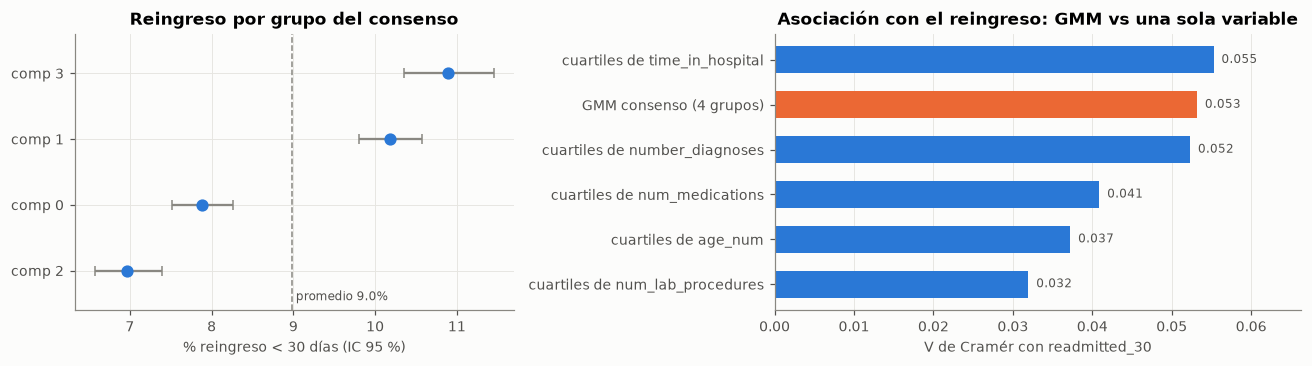

,V de Cramér,p-valor (chi²)
cuartiles de time_in_hospital,0.0553,0.0
GMM consenso (4 grupos),0.0532,0.0
cuartiles de number_diagnoses,0.0523,0.0
cuartiles de num_medications,0.0409,0.0
cuartiles de age_num,0.0372,0.0
cuartiles de num_lab_procedures,0.0319,0.0


In [24]:
yv = d['readmitted_30'].to_numpy()

def wilson(k, n, z=1.96):
    p, den = k / n, 1 + z**2 / n
    centro = (p + z**2 / (2 * n)) / den
    m = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / den
    return centro - m, centro + m

def v_cramer(grupos):
    tb = pd.crosstab(grupos, yv)
    chi2, p, *_ = chi2_contingency(tb, correction=False)
    return np.sqrt(chi2 / (tb.values.sum() * (min(tb.shape) - 1))), p

tasas = pd.DataFrame([{'grupo': f'comp {k}', 'pacientes': (lab_cons == k).sum(), 'tasa <30': yv[lab_cons == k].mean(),
                       'IC 2.5 %': wilson(yv[lab_cons == k].sum(), (lab_cons == k).sum())[0],
                       'IC 97.5 %': wilson(yv[lab_cons == k].sum(), (lab_cons == k).sum())[1]} for k in range(K_FINAL)]).set_index('grupo')
display(tasas.round(3))

asoc = {'GMM consenso (4 grupos)': v_cramer(lab_cons)}
for c in ['time_in_hospital', 'num_medications', 'number_diagnoses', 'age_num', 'num_lab_procedures']:
    asoc[f'cuartiles de {c}'] = v_cramer(pd.qcut(d[c].rank(method='first'), 4, labels=False))
asoc = pd.DataFrame(asoc, index=['V de Cramér', 'p-valor (chi²)']).T.sort_values('V de Cramér', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4), gridspec_kw={'width_ratios': [1, 1.2]})
t_ = tasas.sort_values('tasa <30')
axes[0].errorbar(t_['tasa <30'] * 100, range(len(t_)), xerr=[(t_['tasa <30'] - t_['IC 2.5 %']) * 100, (t_['IC 97.5 %'] - t_['tasa <30']) * 100],
                 fmt='o', color=C[0], ecolor=MUTED, capsize=3, ms=7)
axes[0].axvline(yv.mean() * 100, color=MUTED, ls='--', lw=1)
axes[0].text(yv.mean() * 100 + 0.05, -0.45, f'promedio {yv.mean():.1%}', color=INK, fontsize=8)
axes[0].set_yticks(range(len(t_)), t_.index); axes[0].set_ylim(-0.6, len(t_) - 0.4)
axes[0].set_xlabel('% reingreso < 30 días (IC 95 %)'); axes[0].set_title('Reingreso por grupo del consenso')
a_ = asoc.iloc[::-1]
axes[1].barh(a_.index, a_['V de Cramér'], color=[C[1] if 'GMM' in i else C[0] for i in a_.index], height=0.6)
for i, v in enumerate(a_['V de Cramér']):
    axes[1].text(v + 0.001, i, f'{v:.3f}', va='center', color=INK, fontsize=8)
axes[1].set_xlim(0, a_['V de Cramér'].max() * 1.2); axes[1].grid(axis='y', visible=False)
axes[1].set_xlabel('V de Cramér con readmitted_30'); axes[1].set_title('Asociación con el reingreso: GMM vs una sola variable')
plt.tight_layout(); plt.show()
asoc.round(4)

- **Los grupos sí se relacionan con el reingreso**, con diferencias estadísticamente claras: la estancia corta con procedimiento reingresa el **7.0 %** (IC 95 % [6.6, 7.4]) y la estancia larga e intensiva el **10.9 %** ([10.4, 11.4]). Los intervalos de los grupos de menor y mayor riesgo no se solapan (p-valor del chi² prácticamente 0).
- **Pero la asociación es débil y no supera a una sola variable:** la V de Cramér de la GMM (**0.053**) es prácticamente igual a la de dividir a los pacientes en cuartiles de **días de hospitalización** (0.055) o de número de diagnósticos (0.052).
- **Conclusión:** como herramienta de **riesgo**, la GMM no agrega información más allá de “cuántos días estuvo hospitalizado”. Su valor es **descriptivo**: resume en 4 perfiles interpretables cómo se combinan estancia, procedimientos, medicamentos y diagnósticos. Para estimar el riesgo de cada paciente, el modelo adecuado es el KNN (que además usa las visitas previas y el destino al alta).

## 10. Conclusiones

| | Primera versión (secciones 2–7) | Revisión (sección 9) |
|---|---|---|
| Elección de K | codo del BIC (sin mínimo) | ICL: sin K claro (el mínimo en K = 7 cambia según el jitter); K = 4 empatado con K = 3 y elegido por interpretabilidad |
| Jitter | 1 realización, no evaluada | estabilidad medida (ARI 0.72 con K = 4) → **consenso de 10 jitters** |
| Estabilidad | ARI entre semillas de la GMM 0.80–0.99 | ARI entre consensos independientes **0.88**; Jaccard por grupo 0.81–0.85 (contra ajustes independientes) |
| Asignaciones inciertas (prob. máx. < 0.7) | 21 % | 26 % (más honesto: pacientes en la frontera) |
| Validación externa | tasas por grupo 6.8–10.9 %, sin IC | 7.0 % [6.6, 7.4] a 10.9 % [10.4, 11.4]; V de Cramér 0.053 ≈ cuartiles de días de hospitalización (0.055) |

1. **La GMM encuentra 4 perfiles de hospitalización estables e interpretables:** mayores con muchos diagnósticos (33 %), estancia corta sin procedimientos (28 %), estancia corta con procedimiento (21 %) y estancia larga e intensiva (18 %). Son los mismos en la primera versión y en el consenso.
2. **No son grupos naturales, sino una forma útil de dividir un continuo.** Ningún criterio señala un K claro (el BIC baja sin parar y el mínimo del ICL cambia según el jitter), el 26 % de los pacientes queda en la frontera entre dos perfiles y los grupos se solapan en PCA.
3. **El jitter era necesario pero introducía azar**, y la primera versión no lo había medido. El **consenso de 10 jitters** lo corrige: la estabilidad sube de ARI 0.71 a 0.88.
4. **Un grupo depende de un artefacto de registro:** el de “mayores con muchos diagnósticos” está formado casi por completo por pacientes con exactamente 9 diagnósticos, el tope del sistema de registro.
5. **Como herramienta de riesgo, la GMM no supera a una sola variable:** sus grupos se asocian con el reingreso igual que los cuartiles de días de hospitalización (V de Cramér 0.053 contra 0.055). Los perfiles de mayor riesgo (estancia larga, 10.9 %; muchos diagnósticos, 10.2 %) son apenas 1.5 veces el de menor riesgo (7.0 %).
6. **Para la presentación:** la GMM sirve para **describir** qué tipos de hospitalización hay; el KNN, para **estimar el riesgo** de cada paciente. El clustering (GMM y DBSCAN) confirma que los pacientes forman un continuo.

**Limitaciones:**
- El jitter es una aproximación: la GMM supone variables continuas y gaussianas, y estos datos son conteos enteros, asimétricos y con topes. El consenso reduce el efecto del azar, pero no cambia ese supuesto.
- La selección de K se hizo sobre una muestra de 20 000 pacientes; el consenso final usa los 69 987.
- La validación externa usa solo el reingreso a 30 días; otros desenlaces (costos, mortalidad) no están en el dataset.